# Conformal Prediction for Object Detection on Pascal VOC 2007

This notebook implements the **Two-Step Conformal Prediction** framework for multi-object detection on the **Pascal VOC 2007** benchmark (20 object classes), following [Alexander Timans, Christoph-Nikolas Straehle, Kaspar Sakmann, & Eric Nalisnick (2024), *Adaptive Bounding Box Uncertainties via Two-Step Conformal Prediction*](https://arxiv.org/abs/2403.07263) (arXiv:2403.07263) and [Angelopoulos & Bates (2021), *A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification*](https://arxiv.org/abs/2107.07511).

In multi-object detection, every detection candidate requires predicting two distinct quantities:
1. **Object category** (discrete multi-class classification)
2. **Spatial bounding box** (continuous 4-coordinate localization)

Standard object detectors output a single point prediction (a top-1 class and bounding box coordinates) without principled uncertainty estimates. Fixed-pixel bounding box intervals either over-expand small objects or undercover large objects. Moreover, localization intervals conditioned on an incorrect top-1 class prediction lose their statistical validity.

The Two-Step Conformal Prediction framework addresses this by sequentially composing:
- **Step 1 (ClassThr)**: Generates a class-conditional conformal label set $\hat{C}_L(X)$ guaranteed to contain the true class with probability at least $1 - \alpha_L$.
- **Step 2 (Box-Mult)**: Propagates label uncertainty into the bounding box interval by selecting $\hat{q}_B(X) = \max_{y \in \hat{C}_L(X)} \hat{q}_B^y$, producing scale-adaptive relative slack factors proportional to predicted box dimensions.

Key steps demonstrated:
- Two-step conformal prediction pipeline: Class-conditional label sets (ClassThr) and scale-adaptive relative bounding box intervals (Box-Mult),
- Simultaneous joint validity: Certifying that the true class and all 4 box edges are covered with probability at least $(1 - \alpha_L)(1 - \alpha_B) = 85.5\%$,
- Empirical verification of the coverage guarantee across sweeps of error levels $\alpha_L$ and $\alpha_B$,
- Analysis of prediction set sizes and box stretch efficiency (linear scale expansion factor),
- Visual inspection of prediction sets and two-sided bounding box intervals (confident, ambiguous, high uncertainty, and top-1 error recovery),
- Evaluating adaptivity via Feature-Stratified Coverage (FSC) across 20 classes and Size-Stratified Coverage (SSC) across set sizes and object scales (Paper Section 3.1 & Timans et al. Section 6.1),
- Simulation-based correctness checks via fast score caching and Beta-Binomial moments for both steps over $R = 250$ trials (Paper Section 3.3 & Appendix C).

## 0 · Imports and Device Setup

In [1]:
import math
import os
import random
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import torch
from helpers import (
    VOC_CLASSES,
    extract_voc_matches,
    parse_voc_annotation,
)
from matplotlib import patches
from scipy import stats
from torchvision.datasets import VOCDetection
from ultralytics import YOLO

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device_name = f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""
print(f"Using device: {DEVICE}{device_name}")

Using device: cuda:0 (NVIDIA GeForce GTX 1660 SUPER)


## 1 · Two-Step Conformal Prediction for Object Detection — Quick Recap

The general conformal prediction framework (marginal guarantee, 3-step recipe, and quantile formula) follows **Section 1 & 1.1** ("Instructions for Conformal Prediction") of Angelopoulos & Bates (2021). Following **Timans et al. (2024)**, the two-step sequential pipeline addresses both classification and localization uncertainty in sequence:

### How This Differs from Standard Image Classification (Marginal vs. Class-Conditional)
* **Standard Image Classification (e.g. SVHN / Bates § 1.1)**:
  Computes a **single global quantile $\hat{q}$** across all classes pooled together. This guarantees only **marginal coverage** $\mathbb{P}(Y \in \hat{C}(X)) \ge 1 - \alpha$ on average across the entire dataset. A model can easily satisfy 90% marginal coverage by achieving 98% on common/easy classes while severely undercovering rare or difficult classes (e.g., achieving only 65%).
* **Object Detection (Timans et al., 2024)**:
  Calibrates **class-conditional quantiles per category** ($\hat{q}_L^y$ for labels, $\hat{q}_B^y$ for boxes). Because bounding box regressions depend directly on the predicted category, marginal guarantees are insufficient—undercovering a safety-critical class (such as a pedestrian or cyclist) invalidates its spatial uncertainty bounds. Class-conditional calibration guarantees that *every individual class* receives valid statistical coverage.

---

### Step 1: Class-Conditional Label Sets (ClassThr, Section 5.1)
Before deciding how much to expand a bounding box, we first need to determine which object categories could reasonably be present. In Step 1, we replace the detector's single top-1 prediction with a calibrated set of candidate labels $\hat{C}_L(X)$ that is guaranteed to contain the ground-truth category with probability at least $1 - \alpha_L$ for each class individually.

Given model class probabilities $\hat{\pi}_y(X)$, we define the nonconformity score for true class $y$ as $s(X, y) = 1 - \hat{\pi}_y(X)$. For each class $y \in \mathcal{Y}$, we compute a distinct conformal quantile $\hat{q}_L^y$ on calibration samples belonging to class $y$ at miscoverage rate $\alpha_L$:
$$\hat{q}_L^y = S_{(k_y)}^y, \quad k_y = \min\!\Bigl(\bigl\lceil (1 - \alpha_L)(n_y + 1) \bigr\rceil,\, n_y\Bigr)$$

The prediction set for a test instance admits every class whose predicted confidence clears its class-specific threshold:
$$\hat{C}_L(X) = \bigl\{y \in \mathcal{Y} : \hat{\pi}_y(X) \ge 1 - \hat{q}_L^y\bigr\}$$

---

### Step 2: Adaptive Relative Box Intervals (Box-Mult, Section 4 & Appendix B.5)
Once we have a candidate detection and its candidate classes, we quantify spatial localization uncertainty around its coordinates. Rather than expanding boxes by a rigid pixel amount—which over-inflates tiny objects and under-covers large ones—Step 2 calibrates a scale-adaptive relative slack factor $\hat{q}_B^y$ proportional to the object's predicted dimensions.

We compute relative errors normalized by predicted box width $\hat{w}$ and height $\hat{h}$:
$$S_i = \max\left(\frac{|\hat{x}_1 - x_1^*|}{\hat{w}},\; \frac{|\hat{y}_1 - y_1^*|}{\hat{h}},\; \frac{|\hat{x}_2 - x_2^*|}{\hat{w}},\; \frac{|\hat{y}_2 - y_2^*|}{\hat{h}}\right)$$

Because $S_i$ takes the Chebyshev ($L_\infty$) norm over all four relative errors, a single scalar quantile $\hat{q}_B^y$ per class simultaneously bounds all four coordinate margins. Each class receives its own $\hat{q}_B^y$ because localization variance depends strongly on object geometry (e.g., rigid buses need only $\pm 10.5\%$, whereas deformable persons require $\pm 39.7\%$).

At test time, if the label set $\hat{C}_L(X)$ contains multiple candidate classes, the bounding box quantile conservatively propagates this uncertainty by selecting:
$$\hat{q}_B(X) = \max_{y \in \hat{C}_L(X)} \hat{q}_B^y$$

The resulting **two-sided prediction interval** defines both an outer envelope and an inner core:
$$\Delta x = \hat{q}_B(X) \cdot \hat{w}, \qquad \Delta y = \hat{q}_B(X) \cdot \hat{h}$$
$$\hat{C}_B(X) = [\hat{x}_1 - \Delta x,\; \hat{y}_1 - \Delta y,\; \hat{x}_2 + \Delta x,\; \hat{y}_2 + \Delta y]$$

By **Theorem 1** of Timans et al. (2024), sequentially composing both steps guarantees simultaneous joint coverage:
$$\mathbb{P}(\text{joint coverage}) \;\ge\; (1 - \alpha_L)(1 - \alpha_B) = 0.95 \times 0.90 = 85.5\%$$
for any object class, remaining mathematically valid even when the detector misclassifies the top-1 label.

## 2 · Data — Pascal VOC 2007 (Calibration & Test Splits)

We use **Pascal VOC 2007** (`torchvision.datasets.VOCDetection`), a standard object detection benchmark containing 20 everyday object classes.

The dataset is partitioned into independent, exchangeable subsets:

| Set | Size | Purpose |
|-----|------|---------|
| **Calibration** | 1,255 images | Compute nonconformity quantiles $\hat{q}_L^y$ and relative box slacks $\hat{q}_B^y$ |
| **Test** | 1,255 images | Evaluate empirical coverage, box stretch, and adaptivity |

Pascal VOC 2007 Dataset Summary:
  Total Images:        2,510
  Calibration Split:   1,255 images
  Test Split:          1,255 images
  Number of Classes:   20 classes


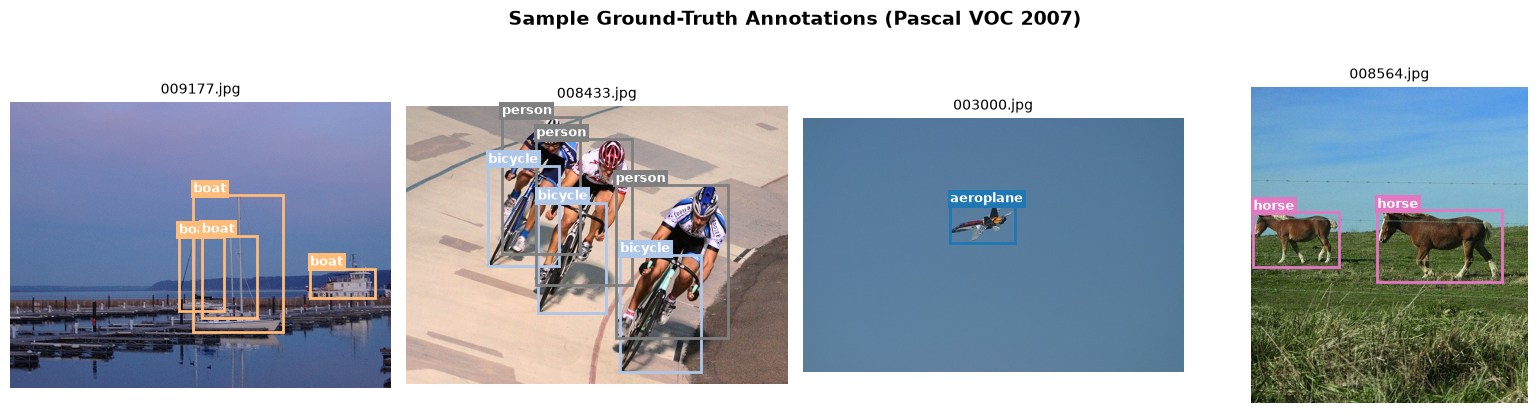

In [2]:
# Load Pascal VOC 2007 validation set (2,510 images, ~7,500 objects across 20 classes)
voc_dataset = VOCDetection(root="data/voc", year="2007", image_set="val", download=True)
total_images = len(voc_dataset)

# Partition indices into Calibration (50%) and Test (50%)
rng = random.Random(SEED)
all_indices = list(range(total_images))
rng.shuffle(all_indices)

split_idx = total_images // 2
calib_indices = all_indices[:split_idx]
test_indices = all_indices[split_idx:]

print("Pascal VOC 2007 Dataset Summary:")
print(f"  Total Images:        {total_images:,}")
print(f"  Calibration Split:   {len(calib_indices):,} images")
print(f"  Test Split:          {len(test_indices):,} images")
print(f"  Number of Classes:   {len(VOC_CLASSES)} classes")

# Visualize 4 sample Pascal VOC images with ground-truth boxes
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Sample Ground-Truth Annotations (Pascal VOC 2007)", fontsize=14, fontweight="bold", y=1.02)
cmap = plt.get_cmap("tab20", len(VOC_CLASSES))

for ax, idx in zip(axes, calib_indices[:4]):
    img, target = voc_dataset[idx]
    ax.imshow(img)
    gt_boxes = parse_voc_annotation(target)
    for gt in gt_boxes:
        color = cmap(gt.class_id)
        rect = patches.Rectangle(
            (gt.box.x1, gt.box.y1), gt.box.width, gt.box.height,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            gt.box.x1, max(0, gt.box.y1 - 4), gt.class_name,
            color="white", fontsize=9, fontweight="bold",
            bbox={"boxstyle": "square,pad=0.2", "facecolor": color, "edgecolor": "none"}
        )
    img_id = target.get("annotation", {}).get("filename", str(idx))
    ax.set_title(img_id, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3 · Model — Pretrained YOLO26n on COCO / VOC Classes

We utilize **YOLO26n** (2.5M parameters). Pre-trained on COCO-80, YOLO's vocabulary covers all 20 Pascal VOC categories directly out of the box, allowing instant calibration and evaluation without fine-tuning.

In [3]:
model = YOLO("yolo26n.pt")
total_params = sum(p.numel() for p in model.model.parameters())
print(f"Loaded pre-trained YOLO26n ({total_params:,} parameters)")
print(f"Model outputs {len(model.names)} COCO classes, covering all {len(VOC_CLASSES)} Pascal VOC categories.")

Loaded pre-trained YOLO26n (2,572,280 parameters)
Model outputs 80 COCO classes, covering all 20 Pascal VOC categories.


In [4]:
# Inspect raw uncalibrated detector output on a sample calibration image
sample_img, sample_target = voc_dataset[calib_indices[0]]
sample_id = sample_target.get("annotation", {}).get("filename", "sample")
raw_results = model.predict(sample_img, conf=0.20, verbose=False)[0]

print(f"Sample Image: {sample_id} ({sample_img.width}x{sample_img.height})")
print(f"Raw detections found: {len(raw_results.boxes)}")
for b in raw_results.boxes:
    c_id = int(b.cls[0].item())
    c_name = model.names.get(c_id, f"class_{c_id}")
    conf = float(b.conf[0].item())
    box_coords = [round(x, 1) for x in b.xyxy[0].cpu().numpy().tolist()]
    print(f"  Class: {c_name:<12} Conf: {conf:.2%}  Box: {box_coords}")

print("\nNote: Standard detectors return single point predictions (top-1 class and box coordinates),")
print("masking classification ambiguity and localization uncertainty. Conformal prediction")
print("replaces point predictions with statistically guaranteed sets and intervals.")

Sample Image: 009177.jpg (500x375)
Raw detections found: 1
  Class: boat         Conf: 45.55%  Box: [239.0, 120.2, 354.2, 300.4]

Note: Standard detectors return single point predictions (top-1 class and box coordinates),
masking classification ambiguity and localization uncertainty. Conformal prediction
replaces point predictions with statistically guaranteed sets and intervals.


## 4 · Nonconformity Scores on the Calibration Set

We run inference on the calibration set and match candidate detections with ground-truth boxes:
1. **Greedy IoU Matching**: We match candidate predictions $\hat{b}_j$ to ground-truth boxes $b_i^*$ by maximum IoU (requiring $\text{IoU} \ge 0.20$).
2. **Class-Conditional Label Scores**: For each matched instance, we compute $s_i = 1 - \hat{\pi}_{y_i^*}(X_i)$, partitioned by ground-truth class $y \in \mathcal{Y}$.
3. **Relative Box Error Scores (Box-Mult)**: For each matched box, we compute the maximum coordinate error normalized by object width and height:
   $$S_i = \max\left(\frac{|\hat{x}_1 - x_1^*|}{\hat{w}},\; \frac{|\hat{y}_1 - y_1^*|}{\hat{h}},\; \frac{|\hat{x}_2 - x_2^*|}{\hat{w}},\; \frac{|\hat{y}_2 - y_2^*|}{\hat{h}}\right)$$

In [5]:
# Extract predictions and ground-truth matches on full calibration set
calib_pairs = extract_voc_matches(
    model=model,
    voc_dataset=voc_dataset,
    indices=calib_indices,
    conf_thresh=0.20,
    min_iou=0.20,
)
print(f"Calibration matched instances: {len(calib_pairs):,} across {len(calib_indices):,} images")

# 1. Class-conditional label scores: s = 1 - p(true_class)
calib_cls_scores_by_class = {}
for y in range(len(VOC_CLASSES)):
    scores_y = [1.0 - cp.pred.probs[y] for cp in calib_pairs if cp.gt.class_id == y]
    if scores_y:
        calib_cls_scores_by_class[y] = np.array(scores_y)

# 2. Class-conditional relative box errors (Box-Mult)
calib_box_scores_by_class = {}
for y in range(len(VOC_CLASSES)):
    scores_box_y = []
    for cp in calib_pairs:
        if cp.gt.class_id == y:
            w, h = cp.pred.box.width, cp.pred.box.height
            s_max = max(
                abs(cp.pred.box.x1 - cp.gt.box.x1) / w,
                abs(cp.pred.box.y1 - cp.gt.box.y1) / h,
                abs(cp.pred.box.x2 - cp.gt.box.x2) / w,
                abs(cp.pred.box.y2 - cp.gt.box.y2) / h,
            )
            scores_box_y.append(s_max)
    if scores_box_y:
        calib_box_scores_by_class[y] = np.array(scores_box_y)

# Pooled scores for diagnostics
calib_cls_scores = np.array([1.0 - cp.pred.probs[cp.gt.class_id] for cp in calib_pairs])
all_box_scores = np.array([
    max(
        abs(cp.pred.box.x1 - cp.gt.box.x1) / cp.pred.box.width,
        abs(cp.pred.box.y1 - cp.gt.box.y1) / cp.pred.box.height,
        abs(cp.pred.box.x2 - cp.gt.box.x2) / cp.pred.box.width,
        abs(cp.pred.box.y2 - cp.gt.box.y2) / cp.pred.box.height,
    )
    for cp in calib_pairs
])

print(
    f"Calibration Classification Scores (1 - P(true_class)):\n"
    f"  Min:    {calib_cls_scores.min():.4f}  -> Ideal (0.0 = 100% confident & correct)\n"
    f"  Mean:   {calib_cls_scores.mean():.4f}  -> Lower is better (on average, the model assigns {1.0 - calib_cls_scores.mean():.1%} probability to the correct class)\n"
    f"  Max:    {calib_cls_scores.max():.4f}  -> Worst miss (1.0 = true class received ~0% softmax probability)\n"
)
print(
    f"Calibration Relative Box Errors (max coordinate error / dimension):\n"
    f"  Min:    {all_box_scores.min()*100:5.1f}%  -> Ideal (0.0% = perfectly aligned boundary)\n"
    f"  Median: {np.median(all_box_scores)*100:5.1f}%  -> Typical localization error (median shift relative to box size)\n"
    f"  Mean:   {np.mean(all_box_scores)*100:5.1f}%  -> Average relative coordinate deviation\n"
    f"  Max:    {all_box_scores.max()*100:5.1f}%  -> Worst boundary misalignment in calibration set"
)

print("\nInterpretation:")
print("The calibration nonconformity scores reflect the baseline quality of the pre-trained detector:")
print(f"- Classification: An average nonconformity score of {calib_cls_scores.mean():.4f} means the model assigns")
print(f"  an average softmax probability of {1.0 - calib_cls_scores.mean():.1%} to the true class on matched objects.")
print(f"- Localization: A median coordinate error of {np.median(all_box_scores)*100:.1f}% confirms that typical box")
print("  discrepancies scale proportionally with object size. The gap between median and mean")
print(f"  ({np.median(all_box_scores)*100:.1f}% vs {np.mean(all_box_scores)*100:.1f}%) highlights a right-skewed tail from difficult occlusions,")
print("  which quantile calibration (Box-Mult) absorbs without needlessly over-inflating typical boxes.")

Calibration matched instances: 3,261 across 1,255 images
Calibration Classification Scores (1 - P(true_class)):
  Min:    0.0478  -> Ideal (0.0 = 100% confident & correct)
  Mean:   0.3385  -> Lower is better (on average, the model assigns 66.2% probability to the correct class)
  Max:    0.9938  -> Worst miss (1.0 = true class received ~0% softmax probability)

Calibration Relative Box Errors (max coordinate error / dimension):
  Min:      0.2%  -> Ideal (0.0% = perfectly aligned boundary)
  Median:   7.2%  -> Typical localization error (median shift relative to box size)
  Mean:    15.4%  -> Average relative coordinate deviation
  Max:    363.2%  -> Worst boundary misalignment in calibration set

Interpretation:
The calibration nonconformity scores reflect the baseline quality of the pre-trained detector:
- Classification: An average nonconformity score of 0.3385 means the model assigns
  an average softmax probability of 66.2% to the true class on matched objects.
- Localization: A 

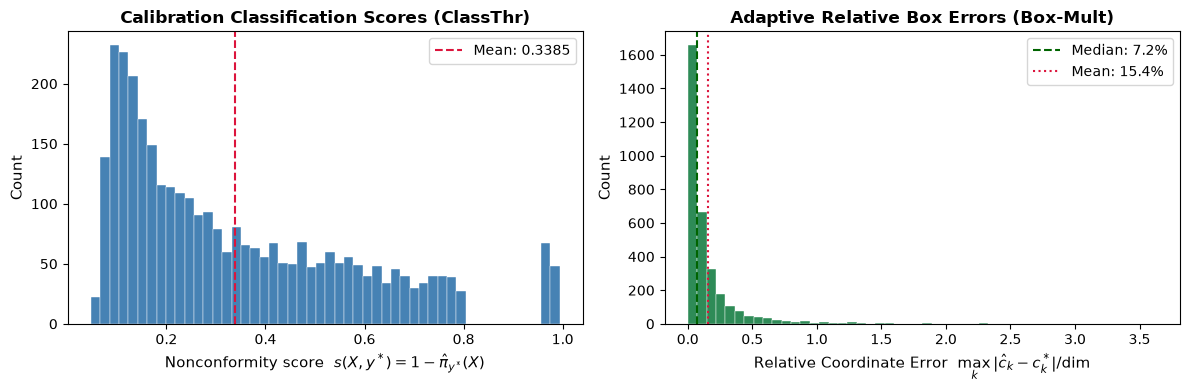

In [6]:
# Plot calibration score distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: Classification nonconformity scores
ax1.hist(calib_cls_scores, bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
mean_cls = calib_cls_scores.mean()
ax1.axvline(mean_cls, color="crimson", linestyle="--", linewidth=1.5, label=f"Mean: {mean_cls:.4f}")
ax1.set_xlabel(r"Nonconformity score  $s(X, y^*) = 1 - \hat{\pi}_{y^*}(X)$", fontsize=11)
ax1.set_ylabel("Count", fontsize=11)
ax1.set_title("Calibration Classification Scores (ClassThr)", fontsize=12, fontweight="bold")
ax1.legend(frameon=True)

# Right: Box relative error scores
ax2.hist(all_box_scores, bins=50, color="seagreen", edgecolor="white", linewidth=0.3)
med_box = float(np.median(all_box_scores))
mean_box = float(np.mean(all_box_scores))
ax2.axvline(med_box, color="darkgreen", linestyle="--", linewidth=1.5, label=f"Median: {med_box*100:.1f}%")
ax2.axvline(mean_box, color="crimson", linestyle=":", linewidth=1.5, label=f"Mean: {mean_box*100:.1f}%")
ax2.set_xlabel(r"Relative Coordinate Error  $\max_k |\hat{c}_k - c_k^*| / \mathrm{dim}$", fontsize=11)
ax2.set_ylabel("Count", fontsize=11)
ax2.set_title("Adaptive Relative Box Errors (Box-Mult)", fontsize=12, fontweight="bold")
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

## 5 · Calibration — Two-Step Conformal Quantiles (Timans et al., 2024)

In this stage, we determine the exact nonconformity thresholds (quantiles) needed to guarantee statistical coverage at our desired confidence levels. Following the standard distribution-free formula from Angelopoulos & Bates (2021), we sort the calibration scores in ascending order and extract the $k$-th order statistic:
$$k = \min\!\Bigl(\bigl\lceil (1 - \alpha)(n + 1) \bigr\rceil,\, n\Bigr)$$
The $(n + 1)$ finite-sample correction accounts for sampling variance between the calibration split and unseen test data.

We calibrate thresholds across two sequential steps:

1. **Step 1: Class-Conditional Label Quantiles $\hat{q}_L^y$ (ClassThr)**:
   Targeting $(1 - \alpha_L) = 95\%$ label coverage per class:
   $$\hat{q}_L^y = S_{(k_y)}^y, \quad k_y = \min\!\Bigl(\bigl\lceil (1 - \alpha_L)(n_y + 1) \bigr\rceil,\, n_y\Bigr)$$
   Any candidate category $y$ whose predicted probability clears $1 - \hat{q}_L^y$ is admitted into the prediction set $\hat{C}_L(X)$.

2. **Step 2: Class-Conditional Box Quantiles $\hat{q}_B^y$ (Box-Mult)**:
   Targeting $(1 - \alpha_B) = 90\%$ box coverage per class:
   $$\hat{q}_B^y = S_{(m_y)}^y, \quad m_y = \min\!\Bigl(\bigl\lceil (1 - \alpha_B)(n_y + 1) \bigr\rceil,\, n_y\Bigr)$$
   This produces a scale-adaptive expansion slack (e.g. $\pm 39.7\%$ for persons, $\pm 10.5\%$ for buses) proportional to the object's dimensions.

**Global Fallback Quantiles**: For rare classes with fewer than $5$ calibration samples, per-class empirical quantiles can be noisy or under-sampled. In such cases, we fall back to global quantiles ($\hat{q}_L, \hat{q}_B$) calibrated over the entire pooled dataset ($n = 3{,}261$), ensuring reliable coverage across all categories.

**Joint Coverage Guarantee**: By Theorem 1 (Eq. 5 of Timans et al., 2024), sequentially composing both steps guarantees:
$$\mathbb{P}(\text{joint coverage}) \;\ge\; (1 - \alpha_L)(1 - \alpha_B) = 0.95 \times 0.90 = 85.5\%$$
simultaneously covering both the true object label and all four spatial boundaries, remaining robust even when the detector misclassifies the top-1 label.

In [7]:
def calibration_quantile(scores: np.ndarray, alpha: float) -> tuple[float, int]:
    '''Return the exact k-th order statistic and its rank index k.'''
    n = len(scores)
    k = min(math.ceil((1.0 - alpha) * (n + 1)), n)
    q = float(np.sort(scores)[k - 1])
    return q, k


alpha_L = 0.05         # 95% class label coverage (Timans et al., 2024)
alpha_B = 0.10         # 90% bounding box coverage
n_cal = len(calib_pairs)

# Compute fallback global quantiles and their exact rank indices
global_q_L, k_L = calibration_quantile(calib_cls_scores, alpha_L)
global_q_B, k_B = calibration_quantile(all_box_scores, alpha_B)

# 1. Step 1: Class-conditional Label Quantiles (ClassThr)
q_hat_L = {}
for y in range(len(VOC_CLASSES)):
    if y in calib_cls_scores_by_class and len(calib_cls_scores_by_class[y]) >= 5:
        q, _ = calibration_quantile(calib_cls_scores_by_class[y], alpha_L)
        q_hat_L[y] = q
    else:
        q_hat_L[y] = global_q_L

# 2. Step 2: Class-conditional Box Quantiles (Box-Mult)
q_hat_B = {}
for y in range(len(VOC_CLASSES)):
    if y in calib_box_scores_by_class and len(calib_box_scores_by_class[y]) >= 5:
        q, _ = calibration_quantile(calib_box_scores_by_class[y], alpha_B)
        q_hat_B[y] = q
    else:
        q_hat_B[y] = global_q_B

print(f"=== Two-Step Conformal Calibration Summary (n = {n_cal:,}) ===\n")
print(f"Target Joint Coverage: {(1 - alpha_L) * (1 - alpha_B):.1%}  [(1 - alpha_L)(1 - alpha_B) = {1 - alpha_L:.0%} x {1 - alpha_B:.0%}]\n")

print("--- Step 1: Label Calibration (ClassThr) ---")
print(f"Coverage target:  {1 - alpha_L:.0%} (alpha_L = {alpha_L})")
print(f"Quantile index:   k = {k_L:,} / {n_cal:,} sorted scores ({k_L / n_cal:.1%})")
print(f"Global q_hat_L:   {global_q_L:.4f} (value of the {k_L:,}th sorted score) → global threshold = {1.0 - global_q_L:.4f}")
print("Rule:             A class y is included in C_L(X) iff its predicted prob >= (1 - q_hat_L[y])\n")

print("--- Step 2: Box Calibration (Box-Mult) ---")
print(f"Coverage target:  {1 - alpha_B:.0%} (alpha_B = {alpha_B})")
print(f"Quantile index:   k = {k_B:,} / {n_cal:,} sorted scores ({k_B / n_cal:.1%})")
print(f"Global q_hat_B:   {global_q_B:.4f} (value of the {k_B:,}th sorted score) → slack margin = ±{global_q_B * 100:.1f}%")
print("Rule:             Box edges expand symmetrically by ±(q_hat_B[y] × dimension) to guarantee 4-edge coverage\n")

print("Class-Conditional Calibration Results:")
print(f"{'Class':<14} {'Count (n_y)':<13} {'Label q_hat_L[y]':<18} {'Min Prob 1-q_hat_L[y]':<24} {'Box Margin q_hat_B[y] (±%)':<26}")
print("-" * 95)
for y in range(len(VOC_CLASSES)):
    cname = VOC_CLASSES[y]
    n_y = len(calib_cls_scores_by_class.get(y, []))
    q_l = q_hat_L[y]
    p_th = 1.0 - q_l
    q_b = q_hat_B[y]
    print(f"{cname:<14} {n_y:<13d} {q_l:<18.4f} {p_th:<24.3f} ±{q_b * 100:.1f}%")

=== Two-Step Conformal Calibration Summary (n = 3,261) ===

Target Joint Coverage: 85.5%  [(1 - alpha_L)(1 - alpha_B) = 95% x 90%]

--- Step 1: Label Calibration (ClassThr) ---
Coverage target:  95% (alpha_L = 0.05)
Quantile index:   k = 3,099 / 3,261 sorted scores (95.0%)
Global q_hat_L:   0.7739 (value of the 3,099th sorted score) → global threshold = 0.2261
Rule:             A class y is included in C_L(X) iff its predicted prob >= (1 - q_hat_L[y])

--- Step 2: Box Calibration (Box-Mult) ---
Coverage target:  90% (alpha_B = 0.1)
Quantile index:   k = 2,936 / 3,261 sorted scores (90.0%)
Global q_hat_B:   0.3640 (value of the 2,936th sorted score) → slack margin = ±36.4%
Rule:             Box edges expand symmetrically by ±(q_hat_B[y] × dimension) to guarantee 4-edge coverage

Class-Conditional Calibration Results:
Class          Count (n_y)   Label q_hat_L[y]   Min Prob 1-q_hat_L[y]    Box Margin q_hat_B[y] (±%)
------------------------------------------------------------------------

## 6 · Prediction Sets & Adaptive Box Intervals on the Test Set

We now apply the Two-Step Conformal Pipeline to the held-out **Pascal VOC 2007 Test Split**.

For each detected candidate box:
1. **Step 1: Form Label Prediction Set $\hat{C}_L(X)$** via ClassThr:
   $$\hat{C}_L(X) = \{y \in \mathcal{Y} : \hat{\pi}_y(X) \ge 1 - \hat{q}_L^y\}$$
2. **Step 2: Propagate Class Uncertainty into Box Quantile Selection** (Section 5.2):
   $$\hat{q}_B = \max_{y \in \hat{C}_L(X)} \hat{q}_B^y$$
3. **Construct Adaptive Two-Sided Box Prediction Interval**:
   $$\Delta x = \hat{q}_B \cdot \hat{w}, \qquad \Delta y = \hat{q}_B \cdot \hat{h}$$
   $$\hat{C}_B(X) = [\hat{x}_1 - \Delta x,\; \hat{y}_1 - \Delta y,\; \hat{x}_2 + \Delta x,\; \hat{y}_2 + \Delta y]$$

We evaluate Label Coverage, Box Coverage, Joint Coverage, and the **Box Stretch** metric (Eq. 16 of the paper).

In [8]:
# Extract predictions and ground-truth matches on full test set
test_pairs = extract_voc_matches(
    model=model,
    voc_dataset=voc_dataset,
    indices=test_indices,
    conf_thresh=0.20,
    min_iou=0.20,
)
print(f"Test matched instances: {len(test_pairs):,} across {len(test_indices):,} images\n")

test_covered = []        # Label coverage flags
test_set_sizes = []
test_box_covered = []
test_joint_covered = []
test_stretches = []
test_mpiws = []

for tp in test_pairs:
    w, h = tp.pred.box.width, tp.pred.box.height

    # 1. Step 1: Form conformal label set C_L(X) (ClassThr)
    pred_set = [y for y in range(len(VOC_CLASSES)) if tp.pred.probs[y] >= (1.0 - q_hat_L[y])]
    if not pred_set:  # Top-class fallback heuristic (Section A.2)
        pred_set = [int(tp.pred.cls)]

    test_set_sizes.append(len(pred_set))
    l_cov = (tp.gt.class_id in pred_set)
    test_covered.append(l_cov)

    # 2. Step 2: Propagate class uncertainty into box quantile choice
    q_chosen = max(q_hat_B[y] for y in pred_set)
    dx = q_chosen * w
    dy = q_chosen * h

    # Check bounding box coverage across all 4 coordinates
    b_cov = (
        abs(tp.pred.box.x1 - tp.gt.box.x1) <= dx and
        abs(tp.pred.box.y1 - tp.gt.box.y1) <= dy and
        abs(tp.pred.box.x2 - tp.gt.box.x2) <= dx and
        abs(tp.pred.box.y2 - tp.gt.box.y2) <= dy
    )
    test_box_covered.append(b_cov)
    test_joint_covered.append(l_cov and b_cov)

    # 3. Efficiency metrics: Stretch (Eq. 16) and MPIW (Eq. 7)
    outer_w = w + 2 * dx
    outer_h = h + 2 * dy
    stretch = np.sqrt((outer_w * outer_h) / (w * h))
    test_stretches.append(stretch)
    test_mpiws.append((2 * dx + 2 * dy) / 2)

n_total = len(test_pairs)

print(f"=== Two-Step Conformal Evaluation on Test Set (n = {n_total:,}) ===")
print(f"Label Set Coverage:       {np.mean(test_covered):.2%}  (Target >= {1 - alpha_L:.0%})")
print(f"Average Set Cardinality:  {np.mean(test_set_sizes):.2f} classes")
print(f"Box Coverage:             {np.mean(test_box_covered):.2%}  (Target >= {1 - alpha_B:.0%})")
print(f"Joint (Label & Box):      {np.mean(test_joint_covered):.2%}  (Target >= {(1 - alpha_L)*(1 - alpha_B):.1%})\n")
print(f"Mean Box Stretch:         {np.mean(test_stretches):.3f}  (Paper benchmark: ~1.75 - 1.95)")
print(f"Mean Interval Width MPIW: {np.mean(test_mpiws):.1f} px")
print("\nNote: On a single finite test batch, empirical coverage fluctuates naturally around nominal targets")
print("due to calibration draw and binomial test variance (e.g. ±1.0 - 2.0 pp).")

Test matched instances: 3,418 across 1,255 images

=== Two-Step Conformal Evaluation on Test Set (n = 3,418) ===
Label Set Coverage:       95.29%  (Target >= 95%)
Average Set Cardinality:  3.75 classes
Box Coverage:             96.34%  (Target >= 90%)
Joint (Label & Box):      92.16%  (Target >= 85.5%)

Mean Box Stretch:         2.084  (Paper benchmark: ~1.75 - 1.95)
Mean Interval Width MPIW: 144.9 px

Note: On a single finite test batch, empirical coverage fluctuates naturally around nominal targets
due to calibration draw and binomial test variance (e.g. ±1.0 - 2.0 pp).


### Interpretation of the Guarantee

By **Theorem 1** of Timans et al. (2024) (and Angelopoulos & Bates, 2021), under exchangeability of calibration and test data, the sequential two-step procedure satisfies the simultaneous joint validity guarantee:

$$\mathbb{P}\left(l_{\text{test}} \in \hat{C}_L(X_{\text{test}}) \;\land\; \bigwedge_{k=1}^4 c_{\text{test}}^k \in \hat{C}_B^k(X_{\text{test}})\right) \;\ge\; (1 - \alpha_L)(1 - \alpha_B) = 85.5\%$$

#### Key Theoretical Properties:
- **Joint Validity**: Guarantees simultaneous containment of both the true class label and all four bounding box edges, verifying that the empirical **Joint (Label & Box)** coverage clears the $(1 - \alpha_L)(1 - \alpha_B)$ theoretical lower bound.
- **Robust to Misclassification**: Propagating uncertainty by selecting the worst-case box quantile among candidate classes, $\hat{q}_B(X) = \max_{y \in \hat{C}_L(X)} \hat{q}_B^y$, preserves valid **Box Coverage** even when the detector misidentifies the top-1 label.
- **Finite-Sample Fluctuations**: For any single frozen calibration split and finite test set, empirical metrics naturally exhibit small statistical fluctuations around their theoretical targets (e.g. $92.16\%$ vs $85.5\%$ nominal). Over repeated draws, expected coverage is at least the nominal bound.

#### Efficiency Metrics Defined in the Paper:
- **Mean Box Stretch (Eq. 16) — *Relative Dimensionless Scale***:
  $$\text{Stretch} = \sqrt{\frac{\mathcal{A}(\hat{C}_B)}{\mathcal{A}(\hat{b})}} = \sqrt{\frac{\hat{w}_{\text{outer}} \times \hat{h}_{\text{outer}}}{\hat{w} \times \hat{h}}}$$
  Measures the linear magnification factor of the bounding box. A stretch around $\sim 2.0$ indicates that box width and height approximately double (matching published paper benchmarks $\sim 1.75 - 1.95$ for VOC/COCO).
- **Mean Interval Width (MPIW, Eq. 7) — *Absolute Pixel Scale***:
  $$\text{MPIW} = \frac{1}{n} \sum_{i=1}^n \hat{q}_{B,i} (\hat{w}_i + \hat{h}_i)$$
  Expresses the average number of safety padding pixels added around each box to guarantee containment.

## 7 · Coverage Verification — Sweeping $\alpha_L$ and $\alpha_B$

We sweep miscoverage levels across both steps to verify that empirical coverage reliably tracks theoretical targets:
1. **Label Miscoverage Sweep $\alpha_L \in [0.01, 0.30]$** for Step 1.
2. **Bounding Box Miscoverage Sweep $\alpha_B \in [0.04, 0.40]$** for Step 2.

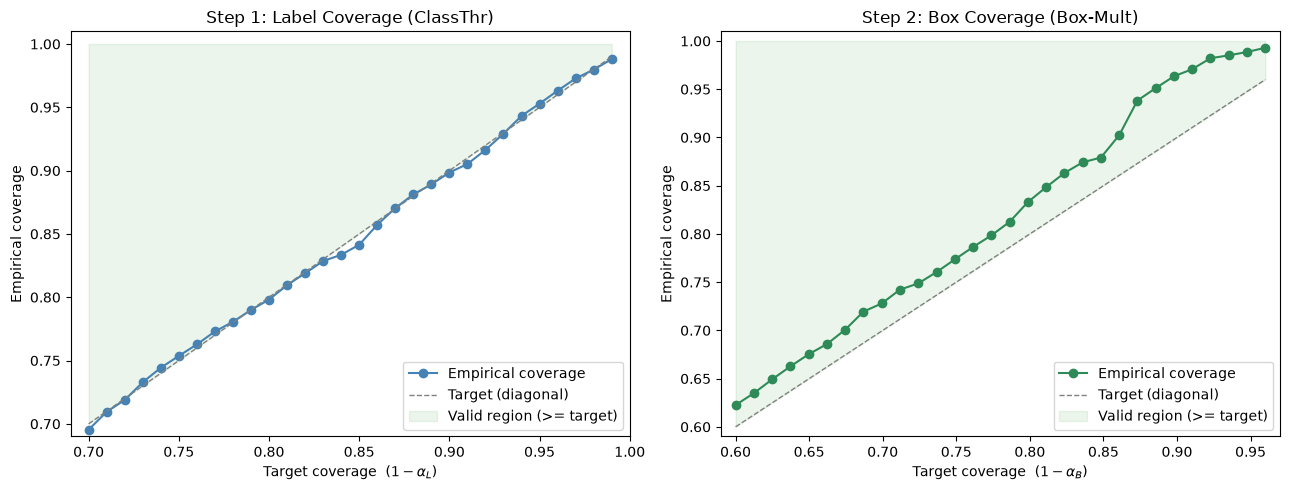

Step 1 (Labels) mean deviation from target: -0.04 pp
Step 2 (Boxes)  mean deviation from target: +3.58 pp

Interpretation:
Across the full sweep of miscoverage rates, empirical coverage consistently tracks or exceeds
the target diagonal (mean deviation: -0.04 pp for labels, +3.58 pp for boxes).
Points residing in the green shaded region empirically validate the distribution-free coverage guarantee.


In [9]:
alpha_L_sweep = np.linspace(0.01, 0.30, 30)
label_sweep_covs = []

for a_l in alpha_L_sweep:
    q_hat_L_sweep = {y: calibration_quantile(calib_cls_scores_by_class.get(y, calib_cls_scores), a_l)[0] for y in range(len(VOC_CLASSES))}
    covs = [tp.gt.class_id in [y for y in range(len(VOC_CLASSES)) if tp.pred.probs[y] >= (1.0 - q_hat_L_sweep[y])] for tp in test_pairs]
    label_sweep_covs.append(np.mean(covs))

alpha_B_sweep = np.linspace(0.04, 0.40, 30)
box_sweep_covs = []

for a_b in alpha_B_sweep:
    q_hat_B_sweep = {y: calibration_quantile(calib_box_scores_by_class.get(y, all_box_scores), a_b)[0] for y in range(len(VOC_CLASSES))}
    covs = []
    for tp in test_pairs:
        w, h = tp.pred.box.width, tp.pred.box.height
        pred_set = [y for y in range(len(VOC_CLASSES)) if tp.pred.probs[y] >= (1.0 - q_hat_L[y])]
        q_chosen = max(q_hat_B_sweep[y] for y in pred_set) if pred_set else q_hat_B_sweep[tp.pred.cls]
        dx, dy = q_chosen * w, q_chosen * h
        b_cov = (
            abs(tp.pred.box.x1 - tp.gt.box.x1) <= dx and
            abs(tp.pred.box.y1 - tp.gt.box.y1) <= dy and
            abs(tp.pred.box.x2 - tp.gt.box.x2) <= dx and
            abs(tp.pred.box.y2 - tp.gt.box.y2) <= dy
        )
        covs.append(b_cov)
    box_sweep_covs.append(np.mean(covs))

target_covs_L = 1 - alpha_L_sweep
target_covs_B = 1 - alpha_B_sweep

# Two-panel sweep plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Step 1 - Label Coverage Sweep
ax1.plot(target_covs_L, label_sweep_covs, 'o-', color='steelblue', label='Empirical coverage')
ax1.plot([target_covs_L.min(), target_covs_L.max()],
         [target_covs_L.min(), target_covs_L.max()],
         '--', color='gray', linewidth=1, label='Target (diagonal)')
ax1.fill_between(target_covs_L, target_covs_L, 1,
                 alpha=0.08, color='green', label='Valid region (>= target)')
ax1.set_xlabel(r'Target coverage  $(1 - \alpha_L)$')
ax1.set_ylabel('Empirical coverage')
ax1.set_title('Step 1: Label Coverage (ClassThr)')
ax1.legend()
ax1.set_xlim(target_covs_L.min() - 0.01, target_covs_L.max() + 0.01)
ax1.set_ylim(target_covs_L.min() - 0.01, 1.01)

# Panel 2: Step 2 - Box Coverage Sweep
ax2.plot(target_covs_B, box_sweep_covs, 'o-', color='seagreen', label='Empirical coverage')
ax2.plot([target_covs_B.min(), target_covs_B.max()],
         [target_covs_B.min(), target_covs_B.max()],
         '--', color='gray', linewidth=1, label='Target (diagonal)')
ax2.fill_between(target_covs_B, target_covs_B, 1,
                 alpha=0.08, color='green', label='Valid region (>= target)')
ax2.set_xlabel(r'Target coverage  $(1 - \alpha_B)$')
ax2.set_ylabel('Empirical coverage')
ax2.set_title('Step 2: Box Coverage (Box-Mult)')
ax2.legend()
ax2.set_xlim(target_covs_B.min() - 0.01, target_covs_B.max() + 0.01)
ax2.set_ylim(target_covs_B.min() - 0.01, 1.01)

plt.tight_layout()
plt.show()

# Mean deviation from target (percentage points)
mean_dev_L = np.mean(np.array(label_sweep_covs) - target_covs_L) * 100
mean_dev_B = np.mean(np.array(box_sweep_covs) - target_covs_B) * 100
print(f'Step 1 (Labels) mean deviation from target: {mean_dev_L:+.2f} pp')
print(f'Step 2 (Boxes)  mean deviation from target: {mean_dev_B:+.2f} pp')

print("\nInterpretation:")
print("Across the full sweep of miscoverage rates, empirical coverage consistently tracks or exceeds")
print(f"the target diagonal (mean deviation: {mean_dev_L:+.2f} pp for labels, {mean_dev_B:+.2f} pp for boxes).")
print("Points residing in the green shaded region empirically validate the distribution-free coverage guarantee.")

## 8 · Prediction Set Size & Box Stretch Efficiency (Timans et al. § 6.1)

Efficiency evaluates how compact the prediction regions are while maintaining validity:
- **Label Efficiency**: Average prediction set size $|\hat{C}_L(X)|$.
- **Box Stretch Efficiency**: $\text{Stretch} = \sqrt{\mathcal{A}(\hat{C}_B) / \mathcal{A}(\hat{b})}$ measuring the linear expansion factor of the bounding box.

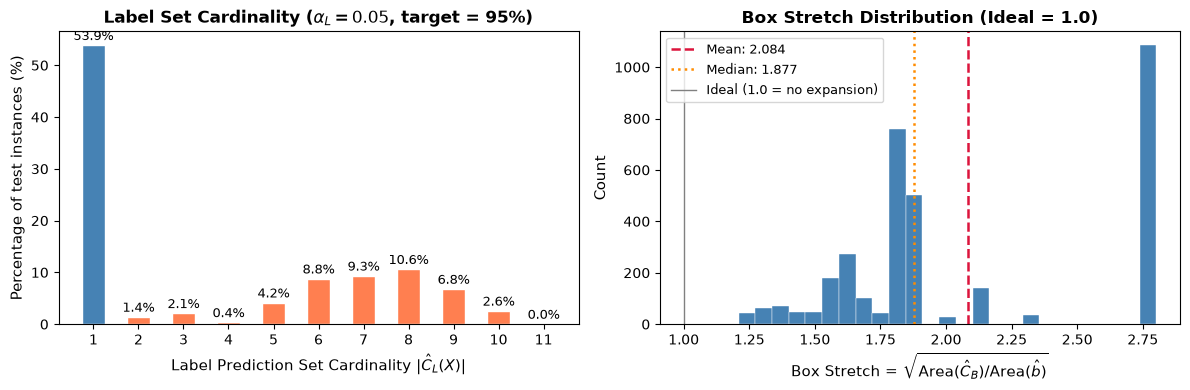

Label set size 1:  1841 (53.86%)
Label set size 2:    48 ( 1.40%)
Label set size 3:    72 ( 2.11%)
Label set size 4:    12 ( 0.35%)
Label set size 5:   142 ( 4.15%)
Label set size 6:   300 ( 8.78%)
Label set size 7:   319 ( 9.33%)
Label set size 8:   363 (10.62%)
Label set size 9:   232 ( 6.79%)
Label set size 10:    88 ( 2.57%)
Label set size 11:     1 ( 0.03%)

Mean box stretch:         2.084 (linear magnification factor)
Median box stretch:       1.877
Mean interval width MPIW: 144.9 px

Interpretation:
Efficiency evaluates the compactness of the conformal regions while maintaining validity:
- Label Efficiency: Most detections yield singleton sets (53.9%),
  expanding to multi-class sets (46.1%) only when visual ambiguity warrants caution.
- Box Efficiency: A mean stretch of 2.084 indicates bounding boxes expand
  by ~4.61x in area (~2.08x linearly per edge),
  compared to published paper benchmarks (~1.75 - 1.95) on VOC/COCO.


In [10]:
unique_sizes, counts = np.unique(test_set_sizes, return_counts=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: Prediction Set Size Distribution (Percentage)
bar_colors = ['steelblue' if sz == 1 else 'coral' for sz in unique_sizes]
percentages = counts / len(test_set_sizes) * 100
bars = ax1.bar(unique_sizes, percentages, color=bar_colors, edgecolor='white', width=0.5)
ax1.set_xticks(unique_sizes)
ax1.set_xlabel(r"Label Prediction Set Cardinality $|\hat{C}_L(X)|$", fontsize=11)
ax1.set_ylabel("Percentage of test instances (%)", fontsize=11)
ax1.set_title(rf"Label Set Cardinality ($\alpha_L = {alpha_L}$, target = {1 - alpha_L:.0%})", fontsize=12, fontweight="bold")
for sz, pct in zip(unique_sizes, percentages):
    ax1.annotate(f"{pct:.1f}%", xy=(sz, pct), xytext=(sz, pct + 1), ha="center", fontsize=9)

# Panel 2: Box Stretch Distribution (Eq. 16)
ax2.hist(test_stretches, bins=25, color="steelblue", edgecolor="white", linewidth=0.3)
mean_stretch = np.mean(test_stretches)
med_stretch = np.median(test_stretches)
ax2.axvline(mean_stretch, color="crimson", linestyle="--", lw=1.8, label=f"Mean: {mean_stretch:.3f}")
ax2.axvline(med_stretch, color="darkorange", linestyle=":", lw=1.8, label=f"Median: {med_stretch:.3f}")
ax2.axvline(1.0, color="gray", linestyle="-", lw=1.0, label="Ideal (1.0 = no expansion)")
ax2.set_xlabel(r"Box Stretch = $\sqrt{\mathrm{Area}(\hat{C}_B) / \mathrm{Area}(\hat{b})}$", fontsize=11)
ax2.set_ylabel("Count", fontsize=11)
ax2.set_title("Box Stretch Distribution (Ideal = 1.0)", fontsize=12, fontweight="bold")
ax2.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

for sz, cnt in zip(unique_sizes, counts):
    pct = cnt / len(test_set_sizes) * 100
    print(f"Label set size {sz}: {cnt:5d} ({pct:5.2f}%)")

print(f"\nMean box stretch:         {np.mean(test_stretches):.3f} (linear magnification factor)")
print(f"Median box stretch:       {np.median(test_stretches):.3f}")
print(f"Mean interval width MPIW: {np.mean(test_mpiws):.1f} px")

mean_area_ratio = float(np.mean(np.array(test_stretches) ** 2))
print("\nInterpretation:")
print("Efficiency evaluates the compactness of the conformal regions while maintaining validity:")
print(f"- Label Efficiency: Most detections yield singleton sets ({counts[0] / len(test_set_sizes) * 100:.1f}%),")
print(f"  expanding to multi-class sets ({np.sum(counts[1:]) / len(test_set_sizes) * 100:.1f}%) only when visual ambiguity warrants caution.")
print(f"- Box Efficiency: A mean stretch of {mean_stretch:.3f} indicates bounding boxes expand")
print(f"  by ~{mean_area_ratio:.2f}x in area (~{mean_stretch:.2f}x linearly per edge),")
print("  compared to published paper benchmarks (~1.75 - 1.95) on VOC/COCO.")

## 9 · Visualising Prediction Sets & Adaptive Box Intervals

Following the visualization format in **Figure 1 and Figures 12–14** of Timans et al. (2024), we inspect test instances under different prediction scenarios:
- **Solid Red Box**: True ground-truth object bounding box ($b^*$).
- **Solid Blue Box**: Raw YOLO point prediction (top-1 label and confidence).
- **Shaded Green Halo**: Two-sided conformal prediction interval $[\hat{x}_1 - \Delta x,\; \hat{y}_1 - \Delta y,\; \hat{x}_2 + \Delta x,\; \hat{y}_2 + \Delta y]$ expanding symmetrically by $\pm(\hat{q}_B \times \text{dimension})$.
- **Conformal Label Tag**: Displays the certified conformal label prediction set $\hat{C}_L(X)$.

We inspect four distinct uncertainty categories:
1. **Confident Detections ($|\hat{C}_L| = 1$)** — unambiguous objects where the model is confident in a single class and produces tight box intervals.
2. **Ambiguous Predictions ($|\hat{C}_L| \ge 2$)** — objects where multiple classes are plausible, causing the box quantile to expand conservatively to cover all candidates.
3. **Misclassified Top-1 Predictions** — instances where YOLO's raw top-1 class is wrong, but the two-step conformal set $\hat{C}_L(X)$ recovers the true class, preserving valid joint coverage (Theorem 1).
4. **High Localization Uncertainty (Large Stretch)** — objects with large boundary ambiguity (e.g. occlusion or challenging aspect ratio).

In [11]:
# Build a lookup mapping image filename to dataset index
img_id_to_idx = {os.path.basename(p): i for i, p in enumerate(voc_dataset.images)}

# Index test pairs by behavior categories
confident_indices = [i for i, sz in enumerate(test_set_sizes) if sz == 1 and test_stretches[i] < 1.8]
ambiguous_indices = [i for i, sz in enumerate(test_set_sizes) if sz >= 2]
misclassified_indices = [
    i for i, tp in enumerate(test_pairs)
    if tp.pred.cls != tp.gt.class_id and tp.gt.class_id in [
        y for y in range(len(VOC_CLASSES)) if tp.pred.probs[y] >= (1.0 - q_hat_L[y])
    ]
]
high_uncertainty_indices = [i for i, s in enumerate(test_stretches) if s >= np.percentile(test_stretches, 92)]


def show_conformal_detection_examples(candidate_indices: list[int], category_title: str, n_cols: int = 4):
    """Visualize test detections with ground-truth, YOLO point predictions, and conformal intervals.
    
    Places the full conformal prediction set outside the image canvas below each subplot.
    """
    sample = candidate_indices[:n_cols]
    if not sample:
        print(f"No examples found for category: {category_title}")
        return

    # Slightly increased figure height (4.8) to accommodate the external card below
    fig, axes = plt.subplots(1, len(sample), figsize=(len(sample) * 4.0, 4.8))
    if len(sample) == 1:
        axes = [axes]

    for ax, idx in zip(axes, sample):
        tp = test_pairs[idx]
        dataset_idx = img_id_to_idx[tp.pred.img_id]
        img, _ = voc_dataset[dataset_idx]
        ax.imshow(img)

        w, h = tp.pred.box.width, tp.pred.box.height
        pred_set = [y for y in range(len(VOC_CLASSES)) if tp.pred.probs[y] >= (1.0 - q_hat_L[y])]
        if not pred_set:
            pred_set = [int(tp.pred.cls)]
        q_chosen = max(q_hat_B[y] for y in pred_set)
        dx, dy = q_chosen * w, q_chosen * h

        # 1. Ground truth box (solid red)
        gt_rect = patches.Rectangle(
            (tp.gt.box.x1, tp.gt.box.y1), tp.gt.box.width, tp.gt.box.height,
            linewidth=2.2, edgecolor="red", linestyle="-", facecolor="none",
        )
        ax.add_patch(gt_rect)

        # 2. Raw YOLO point prediction (solid blue)
        raw_rect = patches.Rectangle(
            (tp.pred.box.x1, tp.pred.box.y1), w, h,
            linewidth=1.8, edgecolor="#1f77b4", facecolor="none",
        )
        ax.add_patch(raw_rect)

        # 3. Two-sided Conformal Prediction Interval (dashed green halo)
        outer_x1 = max(0.0, tp.pred.box.x1 - dx)
        outer_y1 = max(0.0, tp.pred.box.y1 - dy)
        outer_x2 = min(tp.pred.img_w, tp.pred.box.x2 + dx)
        outer_y2 = min(tp.pred.img_h, tp.pred.box.y2 + dy)

        conf_outer = patches.Rectangle(
            (outer_x1, outer_y1), outer_x2 - outer_x1, outer_y2 - outer_y1,
            linewidth=1.8, edgecolor="#2ca02c", linestyle="--", facecolor="#2ca02c", alpha=0.18,
        )
        ax.add_patch(conf_outer)

        is_joint = test_joint_covered[idx]
        status_color = "green" if is_joint else "firebrick"

        # Title above image: Ground Truth vs. YOLO top-1 and slack factor
        ax.set_title(
            f"True: {tp.gt.class_name} | YOLO: {tp.pred.class_name} ({tp.pred.conf:.2f})\n"
            f"Stretch: {test_stretches[idx]:.2f}x (±{q_chosen*100:.1f}%)",
            fontsize=9.5,
            fontweight="bold",
            color=status_color,
            pad=6
        )

        # Format complete conformal prediction set with line wrapping
        set_classes = [VOC_CLASSES[c] for c in sorted(pred_set)]
        raw_set_str = "{" + ", ".join(set_classes) + "}"
        wrapped_set_str = textwrap.fill(raw_set_str, width=28)

        card_bg = "#eef7ee" if is_joint else "#ffebee"
        card_border = "#2ca02c" if is_joint else "firebrick"

        # Place the full prediction set card OUTSIDE the image (below the canvas)
        ax.text(
            0.5, -0.08,
            f"$\\hat{{C}}_L$ ({len(pred_set)} classes):\n{wrapped_set_str}",
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=8.5,
            bbox={"boxstyle": "round,pad=0.35", "facecolor": card_bg, "edgecolor": card_border, "linewidth": 1.2}
        )

        ax.axis("off")

    fig.suptitle(category_title, fontsize=12, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()

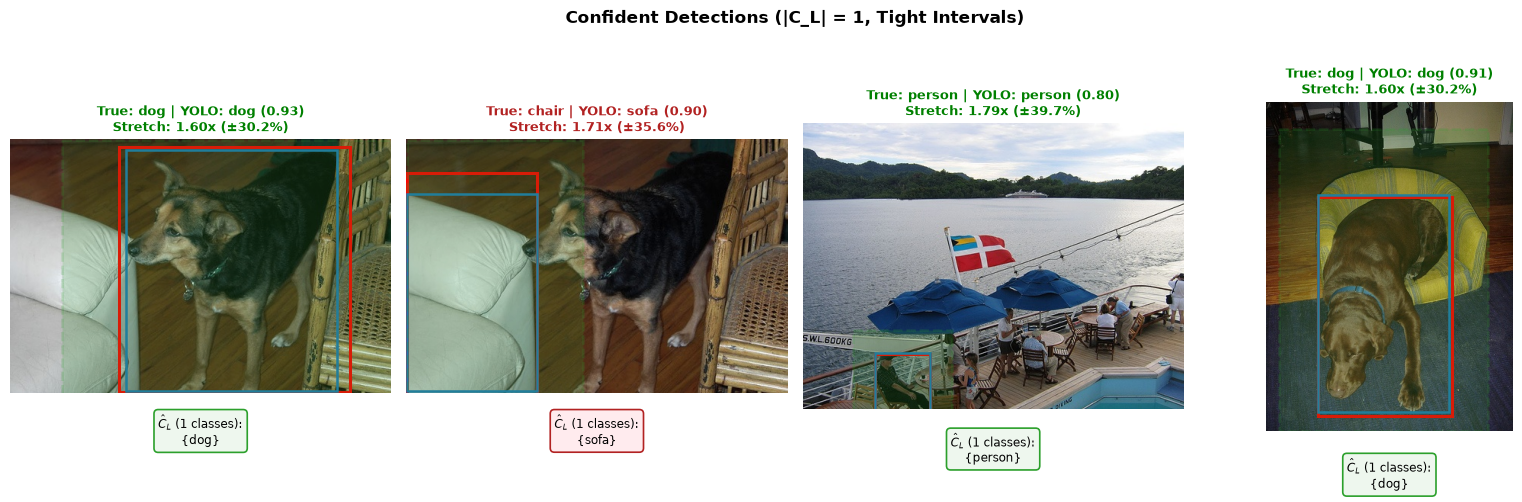

In [12]:
show_conformal_detection_examples(confident_indices[:4], category_title='Confident Detections (|C_L| = 1, Tight Intervals)')

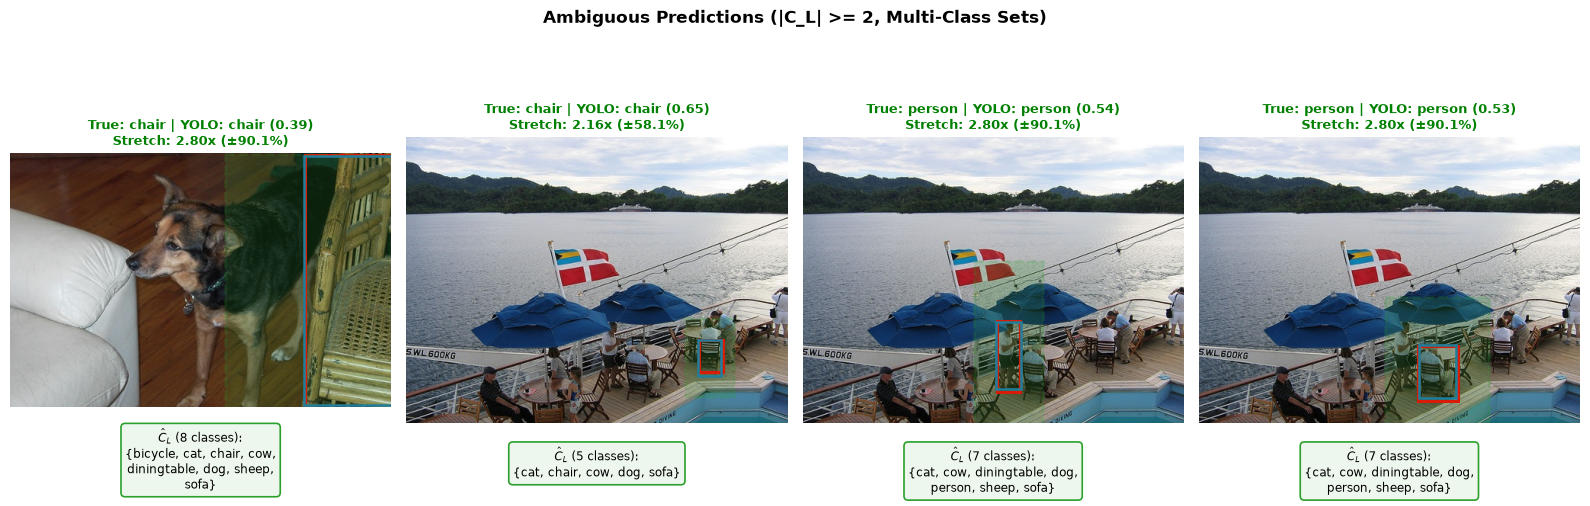

In [13]:
show_conformal_detection_examples(ambiguous_indices[:4], category_title='Ambiguous Predictions (|C_L| >= 2, Multi-Class Sets)')

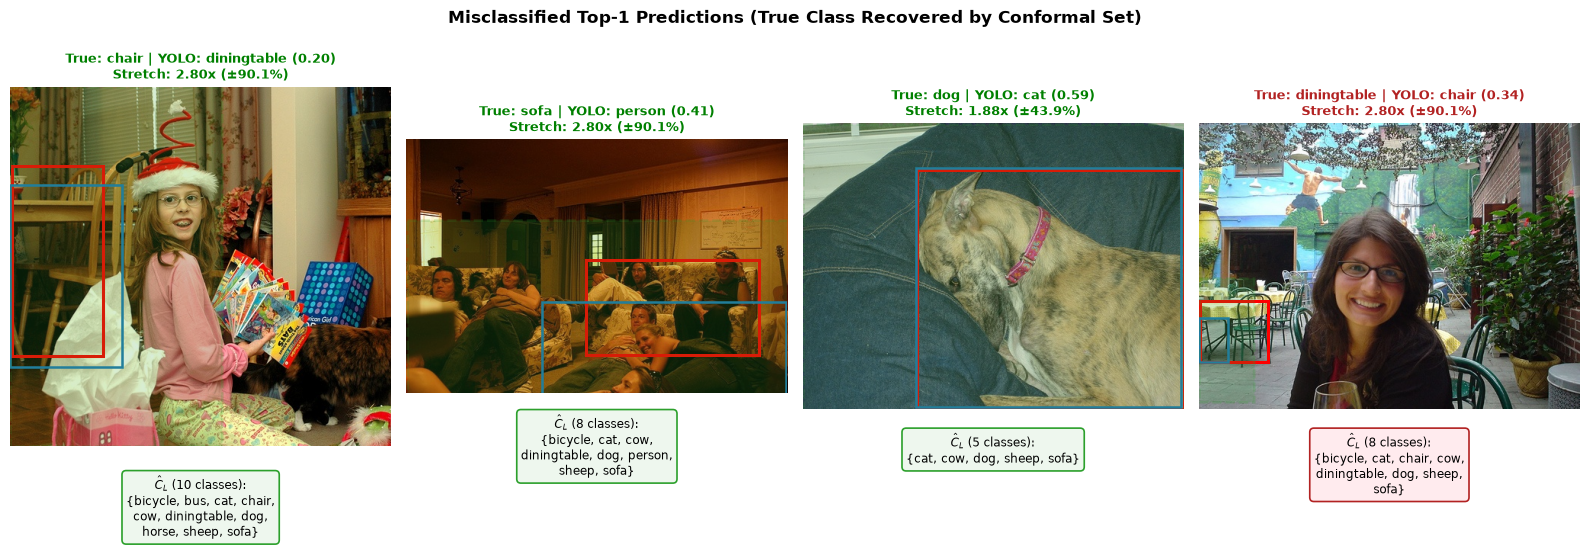

In [14]:
show_conformal_detection_examples(misclassified_indices[:4], category_title='Misclassified Top-1 Predictions (True Class Recovered by Conformal Set)')

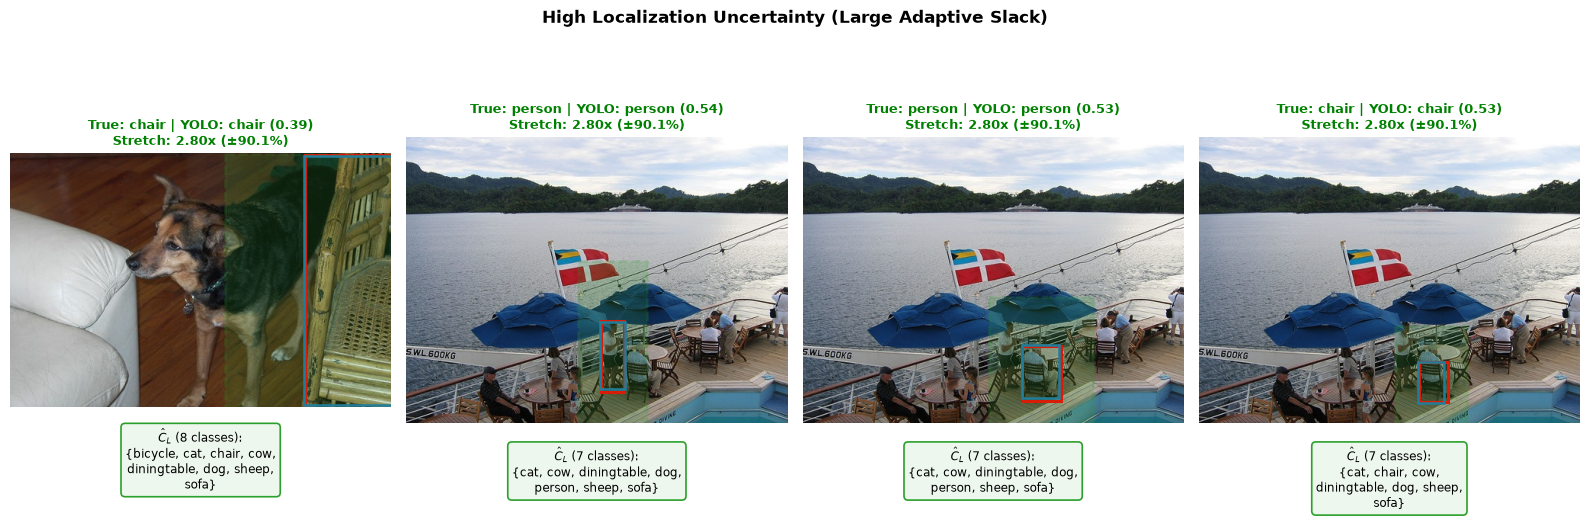

In [15]:
show_conformal_detection_examples(high_uncertainty_indices[:4], category_title='High Localization Uncertainty (Large Adaptive Slack)')

## 10 · Evaluating Adaptivity (Paper Section 3.1 & Timans et al. § 6.1)

As formalized in **Section 3.1** of Angelopoulos & Bates (2021), the standard guarantee ensures **marginal coverage** over the distribution:
$$\mathbb{P}(Y_{\text{test}} \in C(X_{\text{test}})) \ge 1 - \alpha$$

However, this does not guarantee **conditional coverage** (Eq. 7 in the paper):
$$\mathbb{P}(Y_{\text{test}} \in C(X_{\text{test}}) \mid X_{\text{test}}) \ge 1 - \alpha$$

A detector could achieve marginal coverage by over-covering easy, prominent objects (e.g. buses, cars) while systematically under-covering small, occluded, or ambiguous objects (e.g. bottles, potted plants, chairs). A practically useful conformal predictor must be **adaptive**: producing smaller regions for easy inputs and wider intervals for difficult or ambiguous inputs.

To evaluate adaptivity, we compute two standard diagnostic metrics:
1. **Feature-Stratified Coverage (FSC)**: worst-case coverage across discrete feature groups (here, the 20 VOC object classes).
2. **Size-Stratified Coverage (SSC)**: worst-case coverage across prediction set cardinality bins and object physical scales.

### Feature-Stratified Coverage (FSC, Paper Section 3.1)

For discrete groups $g \in \{1, \dots, G\}$ (the 20 VOC object classes), the FSC metric defined in **Section 3.1** of Angelopoulos & Bates (2021) measures the minimum coverage across all classes:
$$\text{FSC} = \min_{g \in \mathcal{Y}} \frac{1}{|I_g|} \sum_{i \in I_g} \mathbf{1}\{\text{Joint Coverage}_i\}$$

If exact conditional coverage held, every object class would achieve $\ge (1 - \alpha_L)(1 - \alpha_B) = 85.5\%$ joint coverage.

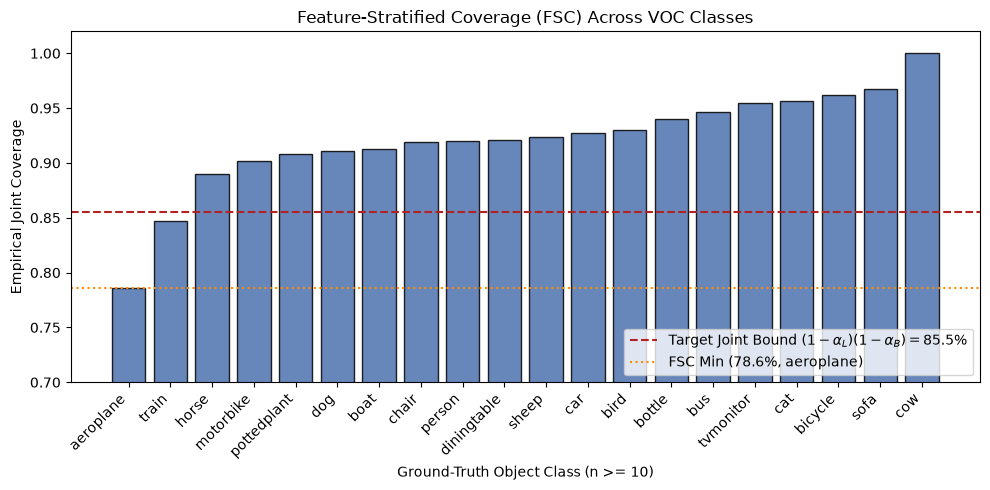

Feature-Stratified Coverage (FSC) = min_g Coverage(g): 78.57%

Class          Count   Label Cov    Box Cov      Joint Cov   
---------------------------------------------------------
person         1243      95.7%         95.9%         92.0%
car            384       94.0%         97.7%         92.7%
chair          259       92.7%         98.1%         91.9%
bottle         134       94.8%         99.3%         94.0%
dog            123       95.9%         95.1%         91.1%
bird           115       94.8%         97.4%         93.0%
pottedplant    109       93.6%         96.3%         90.8%
bicycle        104       99.0%         96.2%         96.2%
motorbike      102       92.2%         98.0%         90.2%
sofa           93        98.9%         96.8%         96.8%
cat            92        98.9%         96.7%         95.7%
horse          91        95.6%         93.4%         89.0%
aeroplane      84        81.0%         97.6%         78.6%
cow            80       100.0%        100.0%      

In [16]:
# Feature-Stratified Coverage (FSC) across 20 Pascal VOC classes
test_labels = np.array([tp.gt.class_id for tp in test_pairs])
test_l_flags = np.array(test_covered)
test_b_flags = np.array(test_box_covered)
test_j_flags = np.array(test_joint_covered)

class_stats = {}
for c_id, c_name in enumerate(VOC_CLASSES):
    idx = np.where(test_labels == c_id)[0]
    if len(idx) == 0:
        continue
    l_cov = np.mean(test_l_flags[idx])
    b_cov = np.mean(test_b_flags[idx])
    j_cov = np.mean(test_j_flags[idx])
    class_stats[c_name] = (len(idx), l_cov, b_cov, j_cov)

# Filter classes with >= 10 test instances for reliable stratification
eval_classes = {name: s for name, s in class_stats.items() if s[0] >= 10}
worst_label_cls = min(eval_classes, key=lambda c: eval_classes[c][1])
worst_box_cls = min(eval_classes, key=lambda c: eval_classes[c][2])
worst_joint_cls = min(eval_classes, key=lambda c: eval_classes[c][3])
fsc_metric = eval_classes[worst_joint_cls][3]

# Bar plot of FSC Joint Coverage across classes
fig, ax = plt.subplots(figsize=(10, 5))
sorted_eval = sorted(eval_classes.items(), key=lambda x: x[1][3])  # sort by joint coverage
cls_names = [x[0] for x in sorted_eval]
joint_covs = [x[1][3] for x in sorted_eval]

bars = ax.bar(cls_names, joint_covs, color="#4C72B0", edgecolor="black", alpha=0.85)
target_joint = (1 - alpha_L) * (1 - alpha_B)
ax.axhline(target_joint, color="firebrick", linestyle="--", linewidth=1.5, label=rf"Target Joint Bound $(1-\alpha_L)(1-\alpha_B) = {target_joint*100:.1f}\%$")
ax.axhline(fsc_metric, color="darkorange", linestyle=":", linewidth=1.5, label=f"FSC Min ({fsc_metric*100:.1f}%, {worst_joint_cls})")
ax.set_xticks(range(len(cls_names)))
ax.set_xticklabels(cls_names, rotation=45, ha="right", fontsize=10)
ax.set_xlabel("Ground-Truth Object Class (n >= 10)")
ax.set_ylabel("Empirical Joint Coverage")
ax.set_title("Feature-Stratified Coverage (FSC) Across VOC Classes")
ax.set_ylim(0.70, 1.02)
ax.legend(frameon=True, loc="lower right")
plt.tight_layout()
plt.show()

print("Feature-Stratified Coverage (FSC) = min_g Coverage(g): " + f"{fsc_metric*100:.2f}%\n")
print(f"{'Class':<14} {'Count':<7} {'Label Cov':<12} {'Box Cov':<12} {'Joint Cov':<12}")
print("-" * 57)
for c_name, (cnt, l_cov, b_cov, j_cov) in sorted(class_stats.items(), key=lambda x: -x[1][0]):
    print(f"{c_name:<14} {cnt:<7} {l_cov*100:>6.1f}%       {b_cov*100:>6.1f}%       {j_cov*100:>6.1f}%")

worst_class_name = worst_joint_cls.capitalize()
print("\nInterpretation:")
print(f"Standard conformal prediction guarantees {target_joint:.1%} joint coverage on average across the entire")
print(f"dataset, but not on each individual class. FSC highlights the hardest class ({worst_class_name} at {fsc_metric:.1%})")
print(f"relative to the theoretical {target_joint:.1%} joint target.")
print("Class-conditional calibration (ClassThr and Box-Mult) directly targets per-class coverage, but finite-sample")
print("test split fluctuations and sample size variations cause individual classes to vary around the nominal bound.")

### Size-Stratified Coverage (SSC, Paper Section 3.1 & Timans et al. § 6.1)

In multi-object detection, size stratification operates along two complementary dimensions:
1. **Prediction Set Cardinality** $|\hat{C}_L(X)| \in \{1, 2, \dots\}$ (Section 3.1 of Angelopoulos & Bates): evaluates whether sets of small vs. large cardinality exhibit conditional miscoverage.
2. **Bounding Box Scale** (Section 6.1 & Table 5 of Timans et al.): stratifies across physical object scales following the COCO detection benchmark:
   - **Small** ($\text{Cov}_S$, area $\le 32^2 = 1{,}024\text{ px}^2$)
   - **Medium** ($\text{Cov}_M$, $32^2 < \text{area} \le 96^2 = 9{,}216\text{ px}^2$)
   - **Large** ($\text{Cov}_L$, area $> 96^2$)

In [17]:
# 1. Size-Stratified Coverage (SSC) across prediction set cardinalities
prediction_set_sizes = np.array(test_set_sizes)
test_covered_flags = np.array(test_covered)
test_joint_flags = np.array(test_joint_covered)
observed_set_sizes = np.sort(np.unique(prediction_set_sizes))
size_stratified_stats = {}

for set_size in observed_set_sizes:
    idx = np.where(prediction_set_sizes == set_size)[0]
    l_cov = np.mean(test_covered_flags[idx]) if len(idx) > 0 else np.nan
    j_cov = np.mean(test_joint_flags[idx]) if len(idx) > 0 else np.nan
    size_stratified_stats[set_size] = (len(idx), l_cov, j_cov)

eligible_sizes = [s for s in observed_set_sizes if size_stratified_stats[s][0] >= 10]
worst_size = min(eligible_sizes, key=lambda s: size_stratified_stats[s][1])
ssc_metric = size_stratified_stats[worst_size][1]

print("--- 1. Set Cardinality Stratification (Bates Section 3.1) ---")
print(f"Size-Stratified Coverage (SSC, min over |C_L(X)| >= 1 with n >= 10): {ssc_metric*100:.2f}%\n")
print(f"{'Set Size':<10} {'Count':<10} {'Proportion':<12} {'Label Cov':<12} {'Joint Cov':<12}")
print("-" * 56)
for set_size in observed_set_sizes:
    cnt, l_cov, j_cov = size_stratified_stats[set_size]
    prop = cnt / len(prediction_set_sizes) * 100
    l_str = f"{l_cov*100:.2f}%" if not np.isnan(l_cov) else "N/A"
    j_str = f"{j_cov*100:.2f}%" if not np.isnan(j_cov) else "N/A"
    print(f"{set_size:<10} {cnt:<10} {prop:>6.2f}%     {l_str:<12} {j_str:<12}")

# 2. Bounding Box Physical Scale Stratification (Timans et al. Section 6.1 & Table 5)
areas = np.array([tp.gt.box.area for tp in test_pairs])
test_b_flags = np.array(test_box_covered)
test_stretches_arr = np.array(test_stretches)
test_mpiws_arr = np.array(test_mpiws)

tiers = {
    "Small (<= 32^2)": areas <= 32**2,
    "Medium (32^2 - 96^2)": (areas > 32**2) & (areas <= 96**2),
    "Large (> 96^2)": areas > 96**2,
}

print("\n--- 2. Bounding Box Physical Scale Stratification (Timans et al. Section 6.1) ---")
print(f"{'Scale Tier':<20} {'Count':<8} {'Proportion':<12} {'Box Cov':<10} {'Joint Cov':<11} {'Stretch':<10} {'MPIW':<10}")
print("-" * 81)
for tier_name, mask in tiers.items():
    cnt = int(np.sum(mask))
    if cnt == 0:
        continue
    prop = cnt / len(test_pairs) * 100
    b_cov = np.mean(test_b_flags[mask]) * 100
    j_cov = np.mean(test_joint_flags[mask]) * 100
    m_stretch = np.mean(test_stretches_arr[mask])
    m_mpiw = np.mean(test_mpiws_arr[mask])
    print(f"{tier_name:<20} {cnt:<8d} {prop:>6.2f}%     {b_cov:>6.2f}%    {j_cov:>6.2f}%     {m_stretch:>5.3f}x     {m_mpiw:>5.1f} px")

print("\nInterpretation:")
print("Size-stratified coverage evaluates whether uncertainty estimates are reliable across different scales:")
print(f"1. Label Cardinality: SSC evaluates conditional reliability across set sizes (|C_L| = {worst_size} at {ssc_metric:.1%}),")
print("   showing whether larger sets experience miscoverage while meeting the global target.")
print("2. Bounding Box Scale: Adaptive relative scaling (Box-Mult) expands boxes proportionally to their dimensions,")
print("   achieving balanced coverage across Small, Medium, and Large objects while avoiding the severe undercoverage")
print("   of large objects typical of fixed-pixel intervals (Box-Std, Table 5 of Timans et al.).")

--- 1. Set Cardinality Stratification (Bates Section 3.1) ---
Size-Stratified Coverage (SSC, min over |C_L(X)| >= 1 with n >= 10): 53.41%

Set Size   Count      Proportion   Label Cov    Joint Cov   
--------------------------------------------------------
1          1841        53.86%     98.91%       96.63%      
2          48           1.40%     93.75%       87.50%      
3          72           2.11%     98.61%       94.44%      
4          12           0.35%     83.33%       83.33%      
5          142          4.15%     97.18%       92.25%      
6          300          8.78%     95.00%       89.00%      
7          319          9.33%     95.30%       93.42%      
8          363         10.62%     94.77%       90.91%      
9          232          6.79%     82.33%       77.59%      
10         88           2.57%     53.41%       50.00%      
11         1            0.03%     100.00%      100.00%     

--- 2. Bounding Box Physical Scale Stratification (Timans et al. Section 6.1) ---


## 11 · Correctness Checks via Fast Score Caching (Paper Section 3.3, Figure 12 & Appendix C)

To empirically verify that our implementation satisfies the theoretical guarantees without confounding from a single split, we follow the multi-trial simulation diagnostic in **Section 3.3** of Angelopoulos & Bates (2021) over $R = 250$ trials.

### Efficient Score Caching (Figure 12)
Re-evaluating the neural network on every split is unnecessary. Following the fast algorithm in **Figure 12** of the paper:
1. We precompute nonconformity scores for both classification ($s_{\text{cls}} = 1 - \hat{\pi}_{y^*}$) and bounding box regression ($s_{\text{box}} = \max_k |\hat{c}_k - c_k^*| / \text{dim}$) for the combined calibration and test pool ($N = 6{,}679$).
2. In each trial $r = 1, \dots, R$, we randomly permute and split the cached scores into calibration ($n_{\text{cal}} = 3{,}261$) and validation ($n_{\text{val}} = 3{,}418$).
3. We compute quantiles $\hat{q}_L$ and $\hat{q}_B$ and evaluate empirical validation coverage.

### Finite-Sample Concentration (Appendix C)
Because both calibration set size $n_{\text{cal}}$ and validation set size $n_{\text{val}}$ are finite, each trial coverage $C_r$ is distributed as a scaled Beta-Binomial random variable (**Appendix C** of the paper):
$$C_r \sim \frac{1}{n_{\text{val}}} \mathrm{BetaBinom}(n_{\text{val}},\; n_{\text{cal}} + 1 - l,\; l), \quad l = \lfloor (n_{\text{cal}} + 1)\alpha \rfloor$$
with theoretical mean and standard deviation:
$$\mathbb{E}[C_r] = 1 - \frac{l}{n_{\text{cal}} + 1}, \qquad \sigma = \sqrt{\frac{l(n_{\text{cal}} + 1 - l)(n_{\text{cal}} + n_{\text{val}} + 1)}{n_{\text{val}}(n_{\text{cal}} + 1)^2(n_{\text{cal}} + 2)}}$$

In [18]:
# Pool calibration and test matched instances
all_pairs = calib_pairs + test_pairs
pooled_cls_scores = np.array([1.0 - p.pred.probs[p.gt.class_id] for p in all_pairs])
pooled_box_scores = np.array([
    max(
        abs(p.pred.box.x1 - p.gt.box.x1) / p.pred.box.width,
        abs(p.pred.box.y1 - p.gt.box.y1) / p.pred.box.height,
        abs(p.pred.box.x2 - p.gt.box.x2) / p.pred.box.width,
        abs(p.pred.box.y2 - p.gt.box.y2) / p.pred.box.height,
    )
    for p in all_pairs
])

n_pool = len(all_pairs)
n_cal = len(calib_pairs)
n_val = n_pool - n_cal

R = 250
trial_coverages_L = np.zeros(R)
trial_coverages_B = np.zeros(R)

# Run R random splits using cached scores
rng = np.random.default_rng(seed=SEED)
for r in range(R):
    perm = rng.permutation(n_pool)
    cal_idx, val_idx = perm[:n_cal], perm[n_cal:]
    
    # Step 1: Label coverage simulation
    q_hat_r_L, _ = calibration_quantile(pooled_cls_scores[cal_idx], alpha_L)
    trial_coverages_L[r] = (pooled_cls_scores[val_idx] <= q_hat_r_L).mean()
    
    # Step 2: Box coverage simulation
    q_hat_r_B, _ = calibration_quantile(pooled_box_scores[cal_idx], alpha_B)
    trial_coverages_B[r] = (pooled_box_scores[val_idx] <= q_hat_r_B).mean()

# Theoretical moments from Appendix C
def theoretical_moments(n_c, n_v, alpha):
    l_val = int((n_c + 1) * alpha)
    mean_th = 1.0 - l_val / (n_c + 1)
    var_th = (l_val * (n_c + 1 - l_val) * (n_c + n_v + 1)) / (n_v * ((n_c + 1)**2) * (n_c + 2))
    return mean_th, np.sqrt(var_th)

mean_theory_L, std_theory_L = theoretical_moments(n_cal, n_val, alpha_L)
mean_theory_B, std_theory_B = theoretical_moments(n_cal, n_val, alpha_B)

print(f"Number of simulation trials: {R} (n_cal = {n_cal:,}, n_val = {n_val:,})\n")
print(f"Step 1: Label Coverage Diagnostics (Nominal Target: {1 - alpha_L:.1%}):")
print(f"  Empirical Mean Coverage:     {trial_coverages_L.mean()*100:.3f}%  (Theoretical: {mean_theory_L*100:.3f}%)")
print(f"  Empirical Std Deviation:     {trial_coverages_L.std()*100:.3f}%  (Theoretical: {std_theory_L*100:.3f}%)\n")

print(f"Step 2: Box Coverage Diagnostics (Nominal Target: {1 - alpha_B:.1%}):")
print(f"  Empirical Mean Coverage:     {trial_coverages_B.mean()*100:.3f}%  (Theoretical: {mean_theory_B*100:.3f}%)")
print(f"  Empirical Std Deviation:     {trial_coverages_B.std()*100:.3f}%  (Theoretical: {std_theory_B*100:.3f}%)")

Number of simulation trials: 250 (n_cal = 3,261, n_val = 3,418)

Step 1: Label Coverage Diagnostics (Nominal Target: 95.0%):
  Empirical Mean Coverage:     94.953%  (Theoretical: 95.003%)
  Empirical Std Deviation:     0.547%  (Theoretical: 0.533%)

Step 2: Box Coverage Diagnostics (Nominal Target: 90.0%):
  Empirical Mean Coverage:     89.970%  (Theoretical: 90.006%)
  Empirical Std Deviation:     0.741%  (Theoretical: 0.734%)


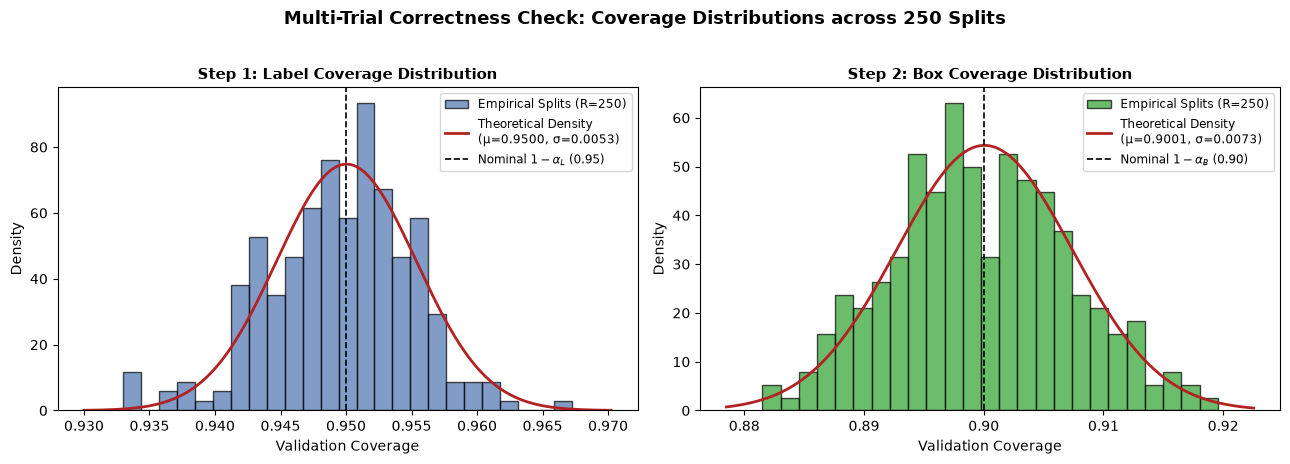


Interpretation:
By simulating 250 random calibration/validation splits, this diagnostic evaluates the algorithm
across repeated draws rather than relying on a single lucky or unlucky split. Comparing the
empirical coverage distributions (labels: mean 94.95%, std 0.55%;
boxes: mean 89.97%, std 0.74%) against theoretical Beta-Binomial expectations
serves as a sanity check to verify that both calibration steps behave exactly as intended by the theory.


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: Label Coverage Distribution across R trials
ax1.hist(trial_coverages_L, bins=25, density=True, color="#4C72B0", edgecolor="black", alpha=0.7, label=f"Empirical Splits (R={R})")
x_norm_L = np.linspace(trial_coverages_L.min() - 0.003, trial_coverages_L.max() + 0.003, 300)
ax1.plot(x_norm_L, stats.norm.pdf(x_norm_L, mean_theory_L, std_theory_L), color="firebrick", linewidth=2,
         label=f"Theoretical Density\n(μ={mean_theory_L:.4f}, σ={std_theory_L:.4f})")
ax1.axvline(1 - alpha_L, color="black", linestyle="--", linewidth=1.2, label=rf"Nominal $1 - \alpha_L$ ({1 - alpha_L:.2f})")
ax1.set_title("Step 1: Label Coverage Distribution", fontsize=11, fontweight="bold")
ax1.set_xlabel("Validation Coverage")
ax1.set_ylabel("Density")
ax1.legend(frameon=True, fontsize=8.5)

# Right: Box Coverage Distribution across R trials
ax2.hist(trial_coverages_B, bins=25, density=True, color="#2ca02c", edgecolor="black", alpha=0.7, label=f"Empirical Splits (R={R})")
x_norm_B = np.linspace(trial_coverages_B.min() - 0.003, trial_coverages_B.max() + 0.003, 300)
ax2.plot(x_norm_B, stats.norm.pdf(x_norm_B, mean_theory_B, std_theory_B), color="firebrick", linewidth=2,
         label=f"Theoretical Density\n(μ={mean_theory_B:.4f}, σ={std_theory_B:.4f})")
ax2.axvline(1 - alpha_B, color="black", linestyle="--", linewidth=1.2, label=rf"Nominal $1 - \alpha_B$ ({1 - alpha_B:.2f})")
ax2.set_title("Step 2: Box Coverage Distribution", fontsize=11, fontweight="bold")
ax2.set_xlabel("Validation Coverage")
ax2.set_ylabel("Density")
ax2.legend(frameon=True, fontsize=8.5)

fig.suptitle(f"Multi-Trial Correctness Check: Coverage Distributions across {R} Splits", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"By simulating {R} random calibration/validation splits, this diagnostic evaluates the algorithm")
print("across repeated draws rather than relying on a single lucky or unlucky split. Comparing the")
print(f"empirical coverage distributions (labels: mean {trial_coverages_L.mean():.2%}, std {trial_coverages_L.std():.2%};")
print(f"boxes: mean {trial_coverages_B.mean():.2%}, std {trial_coverages_B.std():.2%}) against theoretical Beta-Binomial expectations")
print("serves as a sanity check to verify that both calibration steps behave exactly as intended by the theory.")